# Confusion Matrices
Conda environment for this notebook is in `development/plots/environment.yml`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import plotting
# standardize colors
from cycler import cycler 

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

In [2]:
prediction_dir = 'predictions/'

y_true = np.argmax(np.load("y_test.npy"), axis=1)
classes = np.load("classes.npy", allow_pickle=True)

In [3]:
def dut_cm(prediction_path, plotname,figsize=(10, 6)):
    y_dut = np.argmax(np.load(prediction_path), axis=1)
    cm = confusion_matrix(y_true, y_dut)

    fig, ax = plt.subplots(figsize=figsize)
    plotting.plot_confusion_matrix(cm, classes, normalize=True, title=plotname)

    #plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"export/CM_{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

Searching for predictions in predictions/
predictions/y_303_hls4ml.npy


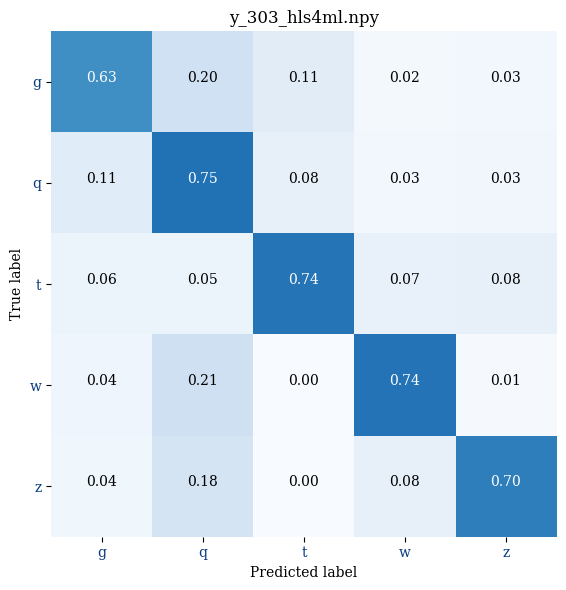

predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_latency_bitfile.npy


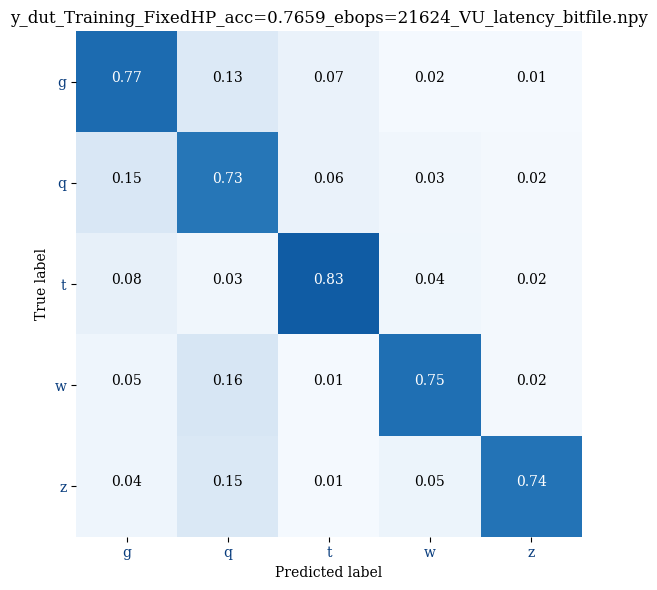

predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_latency_bitfile.npy


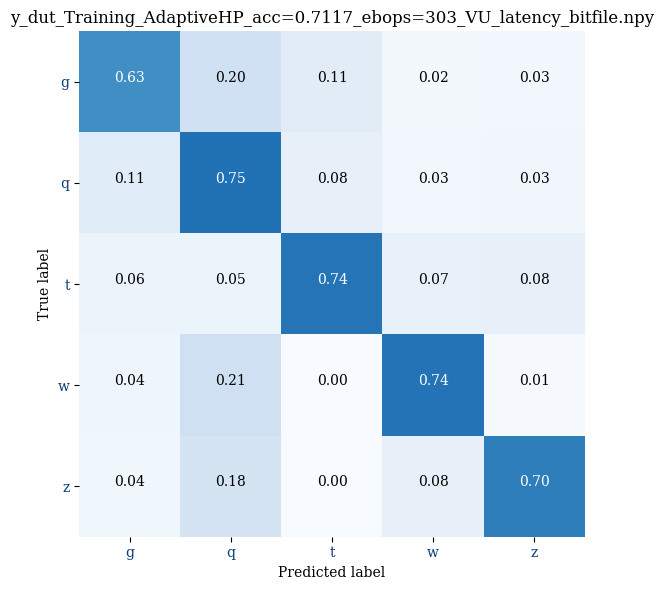

predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_DA_bitfile.npy


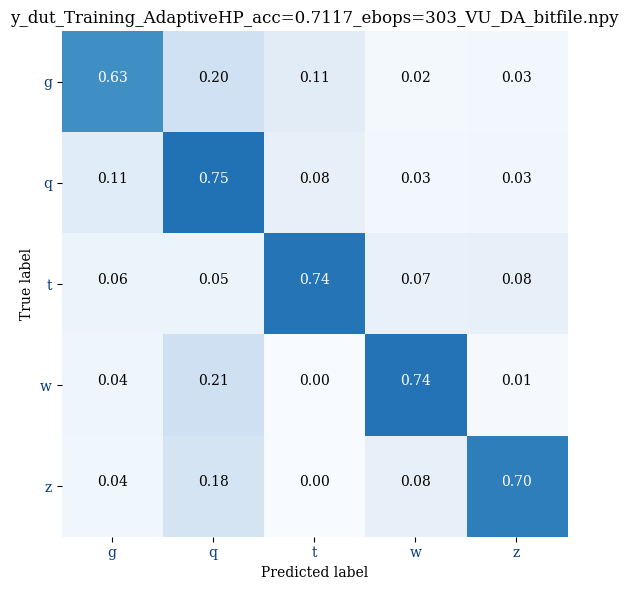

predictions/y_dut_Training_AdaptiveHP_acc=0.7512_ebops=2895_VU_DA_bitfile.npy


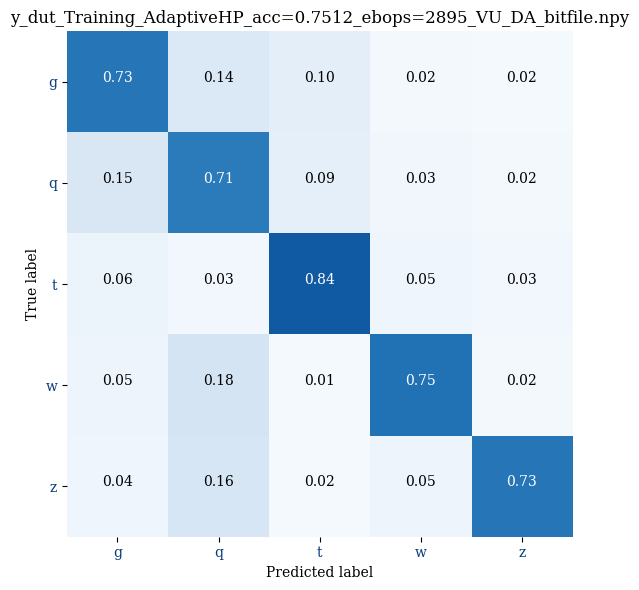

predictions/y_dut_Training_AdaptiveHP_acc=0.7426_ebops=1001_VU_DA_bitfile.npy


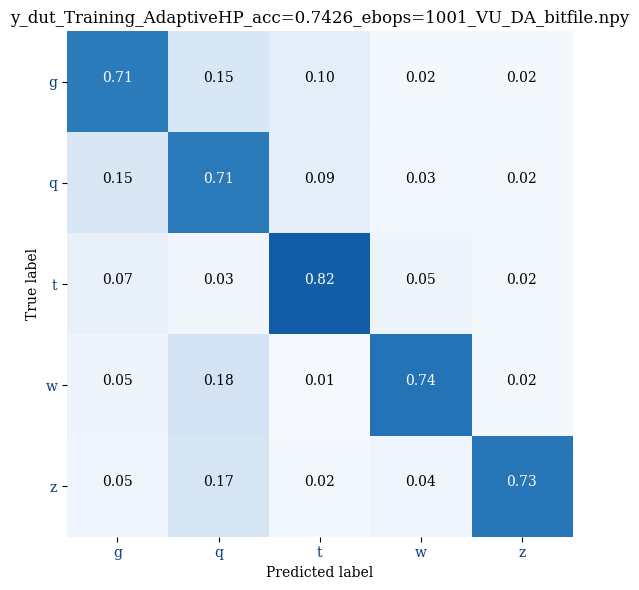

predictions/y_dut_QKeras_acc=0.7298_VU_DA_bitfile.npy


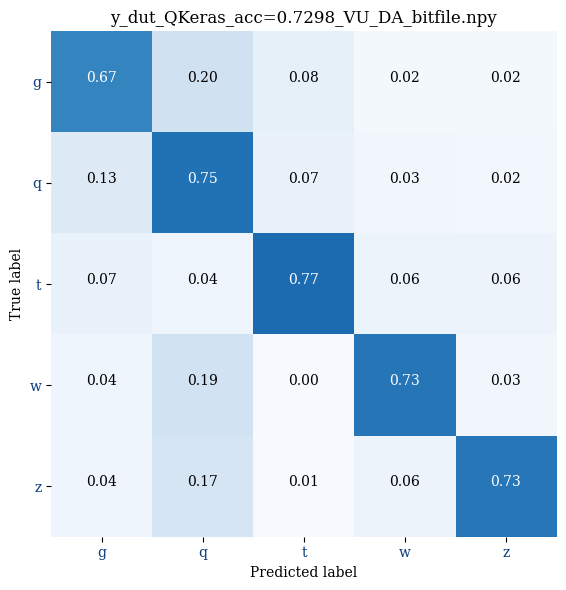

predictions/y_303_keras.npy


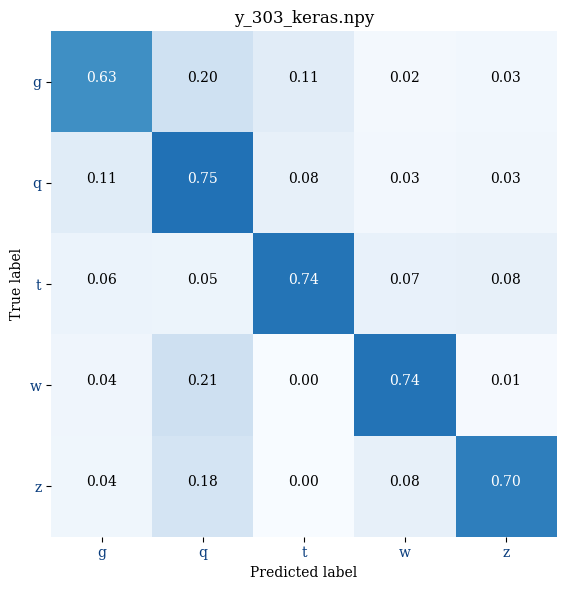

predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_DA_bitfile.npy


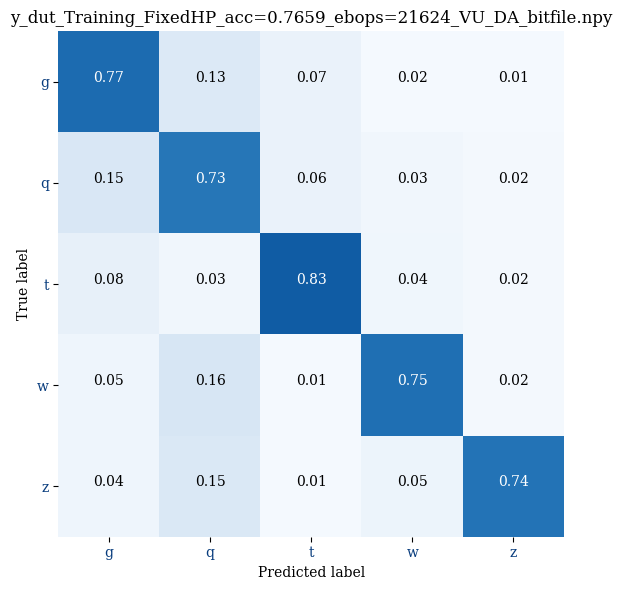

predictions/y_dut_Training_FixedHP_acc=0.7590_ebops=11634_VU_DA_bitfile.npy


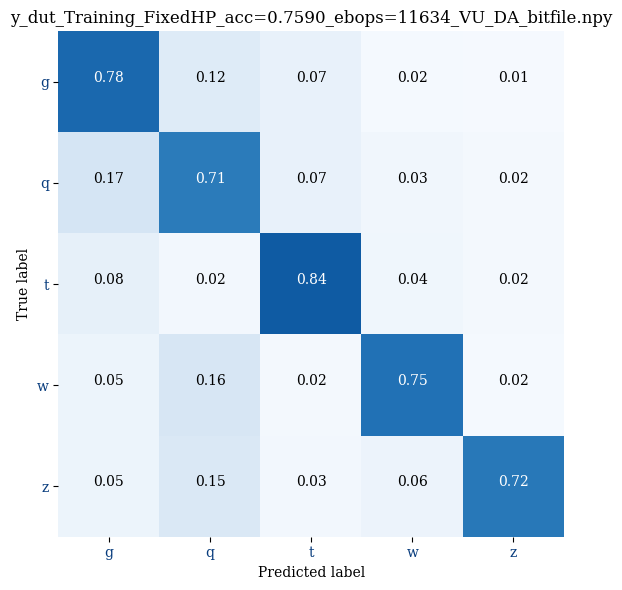

In [4]:
from pathlib import Path


paths = []

print(f"Searching for predictions in {prediction_dir}")
for prediction_path in Path(prediction_dir).rglob('*.npy'):
    print(prediction_path)
    dut_cm(prediction_path, str(prediction_path.name))
    paths.append(prediction_path)

Choose the plots you want to finalize for report

In [5]:
for p in paths:
    print(p)

predictions/y_303_hls4ml.npy
predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_latency_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_latency_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_DA_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7512_ebops=2895_VU_DA_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7426_ebops=1001_VU_DA_bitfile.npy
predictions/y_dut_QKeras_acc=0.7298_VU_DA_bitfile.npy
predictions/y_303_keras.npy
predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_DA_bitfile.npy
predictions/y_dut_Training_FixedHP_acc=0.7590_ebops=11634_VU_DA_bitfile.npy


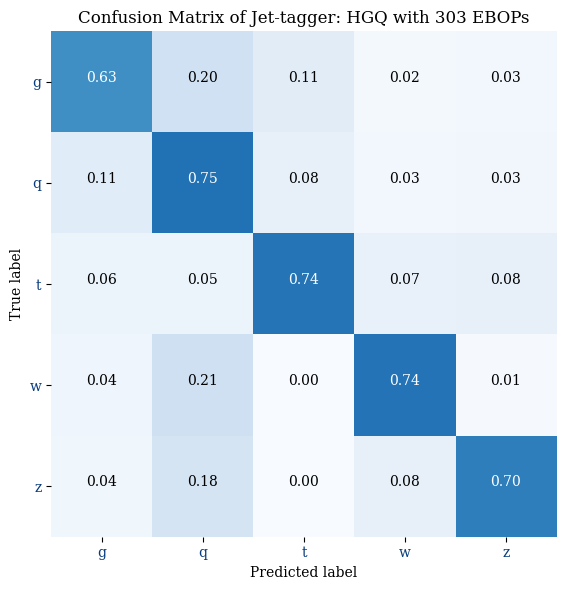

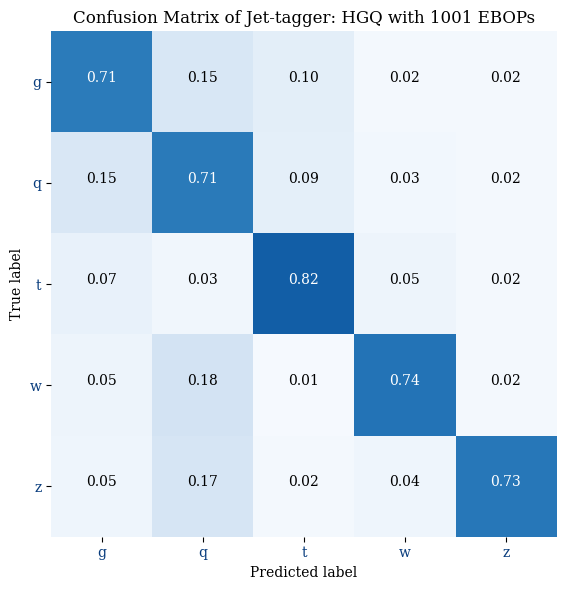

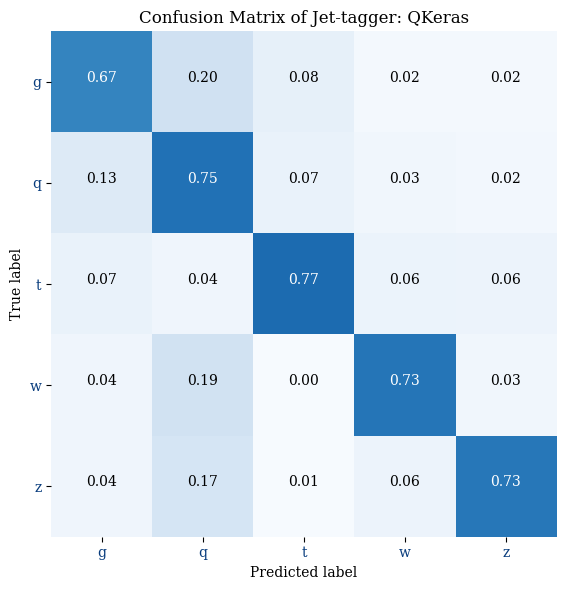

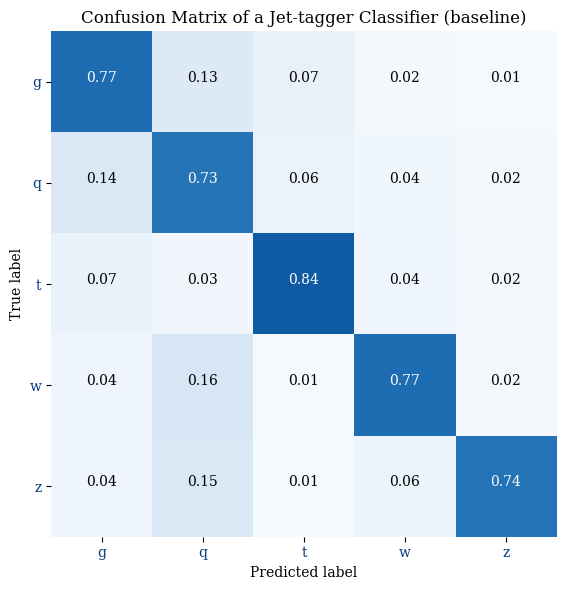

In [7]:
#prediction_path = 'predictions/y_dut_QKeras_acc=0.7298_VU_DA_bitfile.npy'
#plotname = 'Confusion Matrix of Inference on FPGA with Jet Tagging QKeras-model'
#dut_cm(prediction_path, plotname)

prediction_path = 'predictions/y_dut_Training_AdaptiveHP_acc=0.7117_ebops=303_VU_latency_bitfile.npy'
plotname = 'Confusion Matrix of Jet-tagger: HGQ with 303 EBOPs'
dut_cm(prediction_path, plotname,figsize=(8,6))
prediction_path = 'predictions/y_dut_Training_AdaptiveHP_acc=0.7426_ebops=1001_VU_DA_bitfile.npy'
plotname = 'Confusion Matrix of Jet-tagger: HGQ with 1001 EBOPs'
dut_cm(prediction_path, plotname,figsize=(8,6))
prediction_path = 'predictions/y_dut_QKeras_acc=0.7298_VU_DA_bitfile.npy'
plotname = 'Confusion Matrix of Jet-tagger: QKeras'
dut_cm(prediction_path, plotname,figsize=(8,6))

plotname = "Confusion Matrix of a Jet-tagger Classifier (baseline)"
dut_cm('y_baseline.npy',plotname,figsize=(8,6))
